# Sub-task 1

### Import neccesary libraries 

In [1]:
import pandas as pd
import sklearn.linear_model as sk
import matplotlib.pyplot as plt
from sklearn import metrics 

In [ ]:
# Read the CSV file without headers and assign column names 'x' and 'y'
df1 = pd.read_csv('regression1.csv', header=None, names=['x', 'y'])

In [ ]:
df1.head(10)

,x,y
0,3.068400,-44.9170
1,0.724200,14.1380
2,-0.082887,-10.1920
3,3.015100,9.7546
4,-0.589490,-11.7520
5,-4.511300,155.8700
6,4.874600,-79.6940
7,2.492500,-8.5891
8,0.786450,12.1990
9,-1.658300,5.9234


### Apply least squares regression
##### Least squares regression aims to fit a straight line (or hyperplane in multiple dimensions) to the data by minimizing the sum of the squared differences (errors) between the actual and predicted values.
##### Following is the function:

$$
E = \sum_{i=1}^{n} (y_i - (\beta_0 + \beta_1 x_i))^2
$$

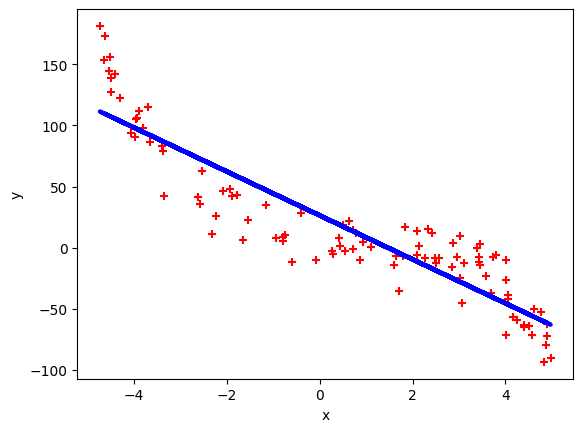

In [ ]:
# Create a Linear Regression model
reg = sk.LinearRegression()

# Fit the model to the data
reg.fit(df1[['x']], df1['y'])

# Scatter plot of the original data points
plt.scatter(df1['x'], df1['y'], marker= '+', color = 'red')

# Use the model to predict y values for the given x values and plot the line 
plt.plot(df1[['x']], reg.predict(df1[['x']]), color = 'blue', linewidth = 3)

plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [5]:
#calculate the coefficient
coefficient = reg.coef_
print(coefficient)

[-17.95952741]


In [ ]:
#calculate the Mean Squared Error (MSE)
mse = metrics.mean_squared_error(df1['y'], reg.predict(df1[['x']]))
print("Mean Squared Error:", mse)

Mean Squared Error: 642.0250234049196


### Drawn conclusion

##### Based on the obtained plot, it is evident that **least squares regression (linear regression) is not well suited** for this dataset. A closer examination of the plot reveals that the data points do not follow a linear trend, making it difficult to accurately fit a linear model to them. Since a significant number of data points deviate substantially from the fitted regression line, the residual errors are quite large. As a result, the **least squares error is high**, indicating that the model fails to capture the underlying relationship effectively. 

# Sub-task 2

### Import neccesary libraries 

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn import metrics

In [ ]:
# Read the CSV file without headers and assign column names 'x' and 'y'
df = pd.read_csv('regression2.csv', header=None, names=['x1', 'x2', 'y'])

In [9]:
df.head(10)

,x1,x2,y
0,1.33440,4.31810,26.554
1,-4.77410,0.40734,-91.444
2,1.24160,4.52560,42.384
3,-2.99810,-2.82540,-16.985
4,-1.02940,1.45030,-14.789
5,-0.34169,2.86220,21.596
6,2.98360,-0.99742,-23.799
7,-2.79000,3.36800,-52.485
8,-1.17610,-3.36950,43.687
9,4.06790,-2.96690,-41.680


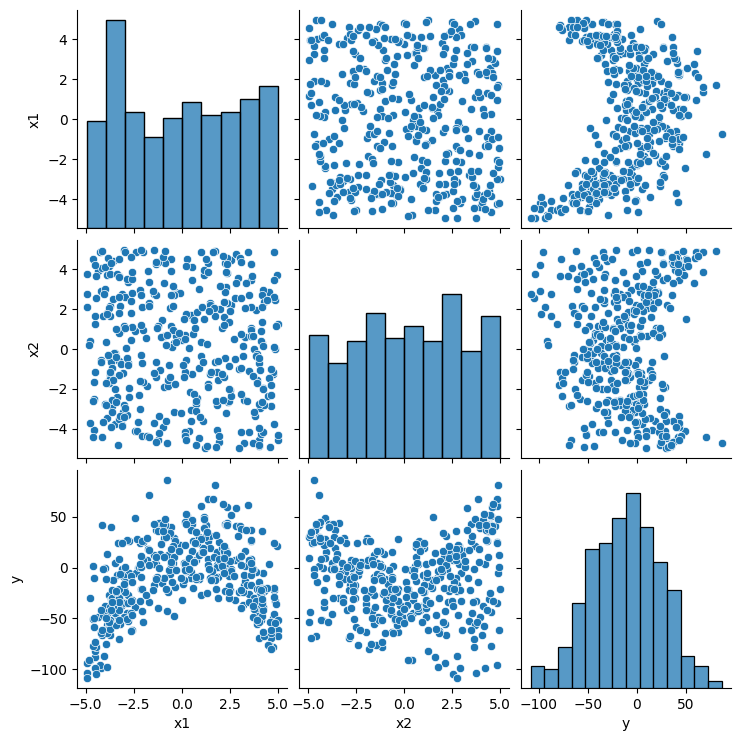

In [10]:
# Create a scatter plot matrix
sns.pairplot(df)
plt.show()


### Model selection

##### The paired scatter plot has shown that the independent variables x1 and x2 exhibit a highly nonlinear relationship with the target variable y. The scatter plots show a curved, non-monotonic pattern, which suggests that linear regression would not be suitable.

##### Recommended Regression Model : Support Vector Regression (SVR)
##### Since the data follows a complex nonlinear pattern, SVR with a  right kernel function can transform the feature space into a higher-dimensional space to capture these relationships.Works well with scattered and complex data structures.

### Data preparation and processing 

In [ ]:

# Split the dataset into training and testing sets 
train, test = train_test_split(df, test_size=0.2, random_state=42)

# Select features 
X_train, X_test = train[['x1','x2']], test[['x1','x2']]

# Select target variable 
y_train, y_test = train['y'], test['y']

# Initialize the StandardScaler, fit it on the training data
scaler = StandardScaler().fit(X_train)

# Transform both the training and testing feature sets using the scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Hyper parameter tuning

##### Selected hyperparameter tuning for Support Vector Regression (SVR) model focuses on exploring different kernel functions: linear, polynomial, radial basis function (RBF), and sigmoid. Since the given dataset exhibits non-linear patterns, choosing the right kernel is crucial to capturing complex relationships between the features and the target variable.

##### Applied GridSearchCV with cross-validation to systematically evaluate and compare the performance of each kernel by choosing neg_mean_squared_error as performance metrics.

In [14]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],  # Different kernel types
}

# Initialize the SVR model with out specify the kernel
svr = SVR()

# Set up GridSearchCV with cross-validation
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Train the model using GridSearchCV on the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Get the best hyperparameters from the grid search
print("Best hyperparameters:", grid_search.best_params_)

Best hyperparameters: {'kernel': 'rbf'}


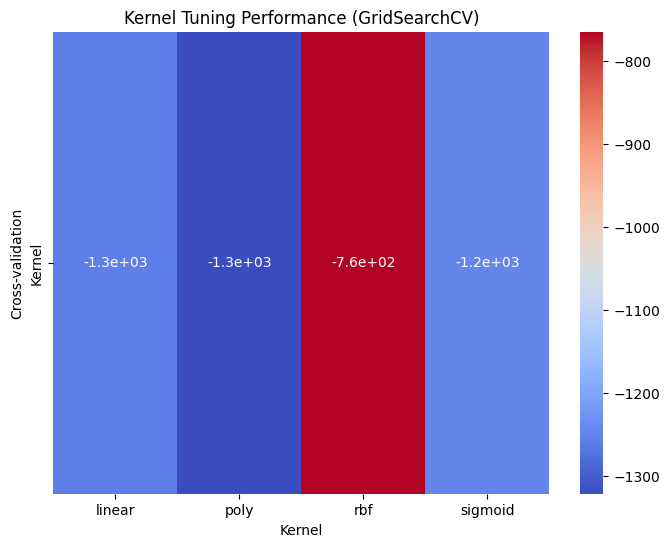

In [7]:
# Create a heatmap to visualize the performance across different kernel types
results = grid_search.cv_results_
scores_matrix = results['mean_test_score'].reshape(1, len(param_grid['kernel']))

plt.figure(figsize=(8, 6))
sns.heatmap(scores_matrix, annot=True, xticklabels=param_grid['kernel'], yticklabels=['Kernel'], cmap='coolwarm')
plt.xlabel('Kernel')
plt.ylabel('Cross-validation')
plt.title('Kernel Tuning Performance (GridSearchCV)')
plt.show()

### Obtain the result from the best model based on the hyperparameter tuning

In [9]:
# Initialize the model 
# Hyper parameter (kernel) : Radial Basis Function (RBF)
svr_rbf = SVR(kernel = 'rbf')

# Train the SVR model using the scaled training data
svr_rbf.fit(X_train_scaled, y_train)

SVR()

Text(0, 0.5, 'y')

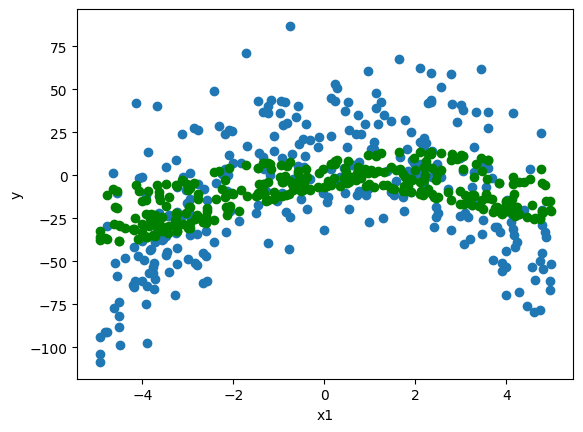

In [10]:
#Model prediction for train dataset 
train['rbf_svr_pred'] = svr_rbf.predict(X_train_scaled)

#Visualization : x1
plt.scatter(train['x1'], train['y'])
plt.scatter(train['x1'], train['rbf_svr_pred'], color = 'green')
plt.xlabel('x1')
plt.ylabel('y')

Text(0, 0.5, 'y')

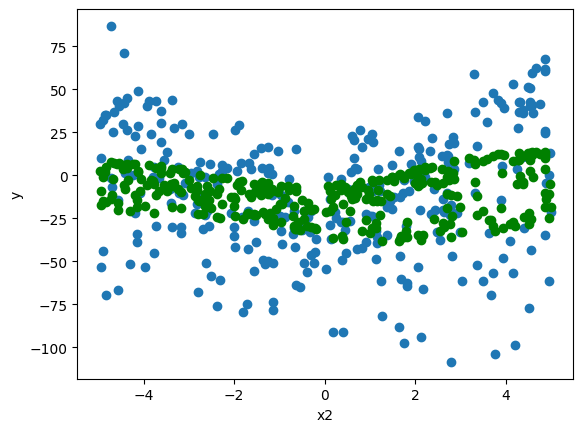

In [11]:
#Visualization : x2
plt.scatter(train['x2'], train['y'])
plt.scatter(train['x2'], train['rbf_svr_pred'], color = 'green')
plt.xlabel('x2')
plt.ylabel('y')

In [18]:
#predict the test result
y_test_pred = svr_rbf.predict(X_test_scaled)

# Test result - metrics
print("R^2 score:", round(metrics.r2_score(y_test, y_test_pred),2))

rmse = round(metrics.mean_squared_error(y_test, y_test_pred),2)
print(f'MSE: {rmse}')


R^2 score: 0.46
MSE: 816.91


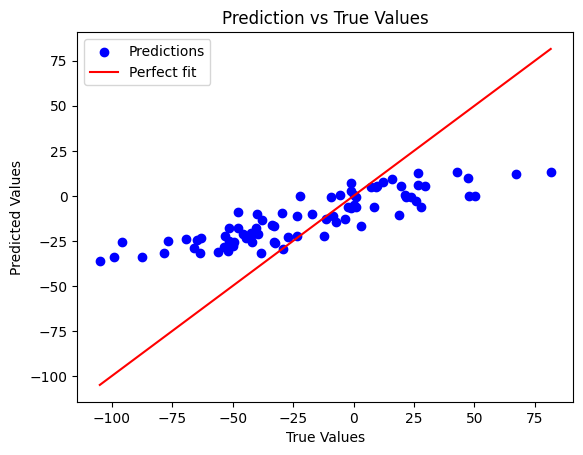

In [13]:
# Scatter plot showing predictions vs true values
plt.scatter(y_test, y_test_pred, color='blue', label='Predictions')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Perfect fit')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Prediction vs True Values')
plt.legend()
plt.show()

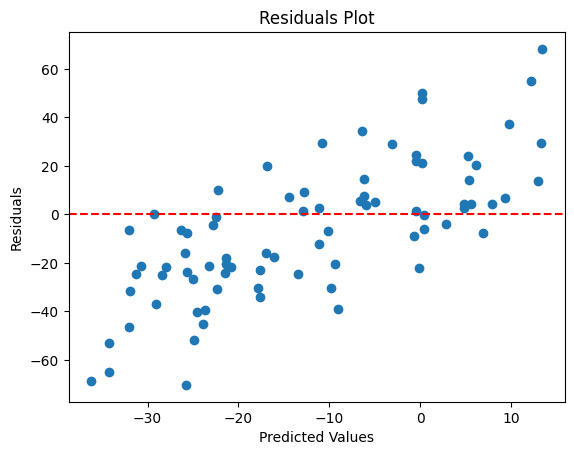

In [14]:
# Plot residuals to check for any patterns in prediction errors
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.show()

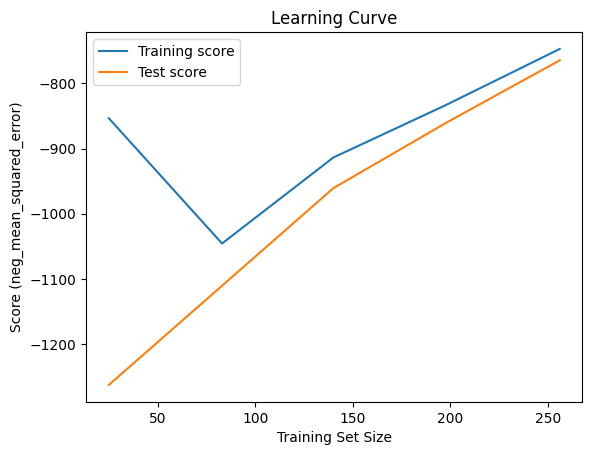

In [17]:
# Plot learning curve to visualize performance with increasing data size
train_sizes, train_scores, test_scores = learning_curve(svr_rbf, X_train_scaled, y_train, cv=5, scoring = 'neg_mean_squared_error')

plt.plot(train_sizes, train_scores.mean(axis=1), label='Training score')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Test score')
plt.xlabel('Training Set Size')
plt.ylabel('Score (neg_mean_squared_error)')
plt.title('Learning Curve')
plt.legend()
plt.show()

### Drawn conclusion

##### The scatter plot matrix reveals a highly nonlinear relationship between the independent variables and the target, necessitating a nonlinear regression model. Support Vector Regression (SVR) was chosen, focusing on optimizing the kernel function for better performance.

##### GridSearchCV with cross-validation was applied using negative mean squared error (neg_mean_squared_error) as the metric. The results showed that the radial basis function (RBF) kernel achieved the lowest error, outperforming other options.Visualizations, including scatter plots, a Prediction vs. True Value plot, a Residuals plot, and a Learning Curve, illustrate the model’s performance and generalization ability.

### References

**Scikit-Learn Documentation:**
- Scikit-Learn, 2025. *sklearn.linear_model.LinearRegression*. Available at: <https://scikitlearn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html> [Accessed 28 February 2025].
- Scikit-Learn, 2025. *sklearn.metrics.mean_squared_error*. Available at: <https://scikitlearn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html> [Accessed 28 February 2025].
- Scikit-Learn, 2025. *sklearn.model_selection.GridSearchCV*. Available at: <https://scikitlearn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html> [Accessed 2 March 2025].
- Scikit-Learn, 2025. *sklearn.model_selection.learning_curve*. Available at: <https://scikitlearn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html> [Accessed 7 March 2025].
- Scikit-Learn, 2025. *sklearn.preprocessing.StandardScaler*. Available at: <https://scikitlearn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html> [Accessed 7 March 2025].
- Scikit-Learn, 2025. *sklearn.svm.SVR*. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html> [Accessed 7 March 2025].